# Proyecto 2 - Algoritmos de mejoramiento de imágenes basado por pixeles

## Equipo: 22

## Integrantes
 - Erick Alan Cuéllar Quintanilla
 - Fanny Betsabé Fuentes Reyes
 - David Felipe Hernández Chiapa
 - José Emmanuel Vázquez Galán

In [1]:
# Bibliotecas

from matplotlib import image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from skimage.color import rgb2ycbcr, ycbcr2rgb

In [2]:
def img_to_np_array(img_path):
    img = Image.open(img_path)
    return np.array(img)

def show_image(img_array):
    if img_array.ndim == 2:
        plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img_array)
    plt.axis("off")
    plt.show()

In [3]:
img1_array = img_to_np_array('data/img1.jpg')
img2_array = img_to_np_array('data/img2.jpg')
img3_array = img_to_np_array('data/img3.jpg')
img4_array = img_to_np_array('data/space.webp')
img5_array = img_to_np_array('data/gamma_c.jpg')
img6_1_array = img_to_np_array('data/img6_1.png')
img6_2_array = img_to_np_array('data/img6_2.png')

### Pregunta 1

Investiga e implementa el método tile-based histogram equalization. En estos métodos, la imagen se particiona en diferentes ventanas (i.e. mosaicos) y los histogramas se calculan de forma independiente, aplicando la corrección sobre cada ventana. Existe un compromiso entre el tamaño de la ventana y la complejidad computacional, por lo cual es más complejo que el método simple. Implementa esta versión y realiza algunas pruebas variando el tamaño de la ventana. Otro inconveniente es que se puede observar posibles diferencias entre los el contraste de los bloques, ¿cómo podría mejorarse?

#### Respuesta

Este método también es conocido como AHE (*Adaptive Histogram Equalization*, por sus siglas en inglés). Puede amplificar el ruido de fondo y los artefactos. El método fue diseñado originalmente para imágenes en blanco y negro (un solo canal); sin embargo, se puede aplicar a imágenes a color si se cambia el espacio de color, por ejemplo, a Lab o YCbCr. Si se utiliza Lab, solo es necesario extraer la componente de luminosidad, aplicar la técnica y, después, reintegrarla para no modificar los colores. La idea es la siguiente:

1. Si la imagen es en blanco y negro, se continúa con el proceso. De lo contrario, se convierte a Lab y se trabaja sobre la componente de luminosidad.
2. La imagen se divide en regiones, las cuales pueden o no sobrelaparse. También se puede agregar *padding* si las dimensiones de la imagen no son suficientes. Todas las regiones tienen el mismo tamaño.
3. Para cada región, se calcula el histograma.
4. Se calcula la función de distribución acumulada para mapear cada píxel de la región a su valor ecualizado.
5. Para cada píxel de la imagen, se calcula su valor final mediante interpolación lineal, basada en las tablas de la función de distribución acumulada de los centros de las regiones más cercanas.
6. Si la imagen era a color, la luminancia procesada se reintegra con los canales de crominancia originales para conservar los tonos originales.

Existen diferentes formas de solucionar el problema de contraste entre regiones. Una de ellas consiste en introducir el concepto de ventanas móviles (*sliding windows*) para calcular histogramas locales. De esta manera, se obtienen histogramas centrados en cada píxel de la imagen. El resultado es bueno, pero calcular los histogramas para una imagen de tamaño $n \times m$ es muy lento.

Otra solución es CLAHE. En lugar de calcular un histograma por cada píxel, este método limita los picos del histograma de luminancia según un valor establecido. Esto evita o mitiga los cuadros visibles entre regiones y resulta más eficiente.

 

In [4]:
def get_image_to_process(img_array):
    is_grayscale = img_array.ndim == 2
    if is_grayscale:
        return img_array, is_grayscale, None
    else:
        img_array_ycbcr = rgb2ycbcr(img_array)
        return img_array_ycbcr[:, :, 0], is_grayscale, img_array_ycbcr

def pad_image_to_fit_kernel(img_to_process, kernel_size_h, kernel_size_w):
    height, width = img_to_process.shape[:2]
    pad_height = (kernel_size_h - height % kernel_size_h) % kernel_size_h
    pad_width = (kernel_size_w - width % kernel_size_w) % kernel_size_w
    if pad_height > 0 or pad_width > 0:
        img_to_process = np.pad(img_to_process, ((0, pad_height), (0, pad_width)), mode='reflect')
    return img_to_process, height, width

def ahe(img_array, kernel_size_h, kernel_size_w, show_hist=False):
    # Determinamos si la imagen es en escala de grises o en color
    img_to_process, is_grayscale, img_array_ycbcr = get_image_to_process(img_array)


    # Dividimos la imagen en regiones de tamaño kernel_size x kernel_size
    # Si la imagen no es divisible exactamente por el tamaño del kernel, podemos agregar padding.
    # Calculamos si requiere padding
    img_to_process, height, width = pad_image_to_fit_kernel(img_to_process, kernel_size_h, kernel_size_w)

    padded_height, padded_width = img_to_process.shape
    tile_rows = padded_height // kernel_size_h
    tile_cols = padded_width // kernel_size_w

    if show_hist:
        fig, axes = plt.subplots(
            tile_rows,
            tile_cols,
            figsize=(3 * tile_cols, 2 * tile_rows),
            sharex=True,
            sharey=True,
            squeeze=False,
        )

    # calculamos el histograma local para cada región
    output_img = np.zeros_like(img_to_process)
    for i in range(0, padded_height, kernel_size_h):
        for j in range(0, padded_width, kernel_size_w):
            local_region = img_to_process[i:i+kernel_size_h, j:j+kernel_size_w]
            hist, bins = np.histogram(local_region.flatten(), 256, [0,256])
            cdf = hist.cumsum()
            cdf_normalized = cdf * 255 / cdf[-1]
            local_region_idx = np.clip(np.rint(local_region), 0, 255).astype(np.uint8)
            output_img[i:i+kernel_size_h, j:j+kernel_size_w] = cdf_normalized[local_region_idx]
            if show_hist:
                ax = axes[i // kernel_size_h, j // kernel_size_w]
                ax.bar(bins[:-1], hist, width=1)
                ax.set_title(f"({i}, {j})", fontsize=8)
                ax.set_xlim(0, 255)

    if show_hist:
        fig.suptitle("Histogramas locales por mosaico")
        fig.tight_layout()
        plt.show()

    output_img = output_img[:height, :width]

    if is_grayscale:
        return output_img

    img_array_ycbcr[:, :, 0] = output_img
    rgb_result = ycbcr2rgb(img_array_ycbcr)

    return np.clip(rgb_result * 255, 0, 255).astype(np.uint8)

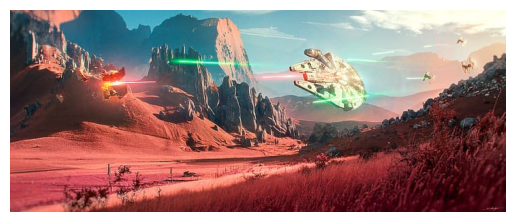

In [5]:
#imagen original
show_image(img1_array)

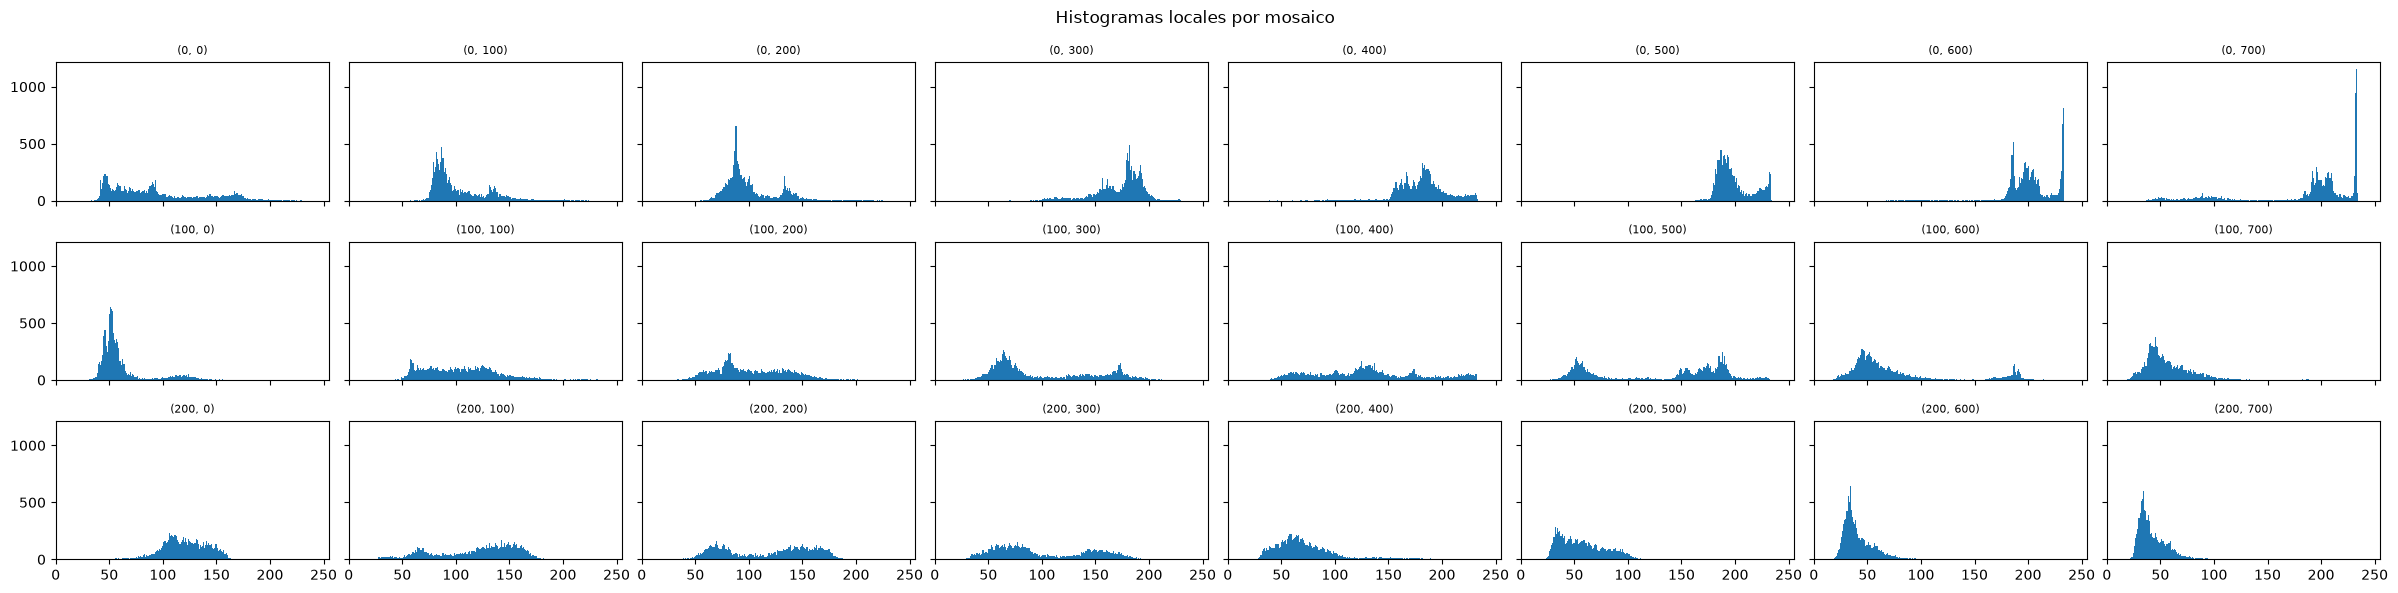

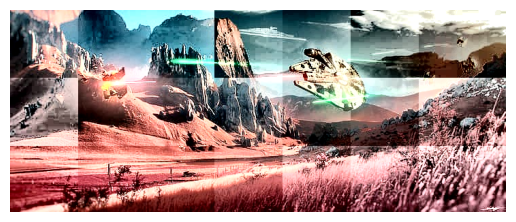

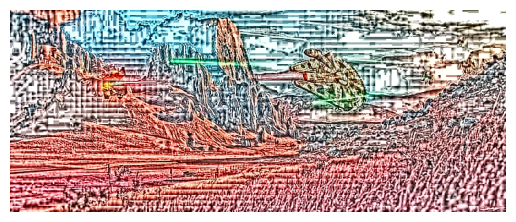

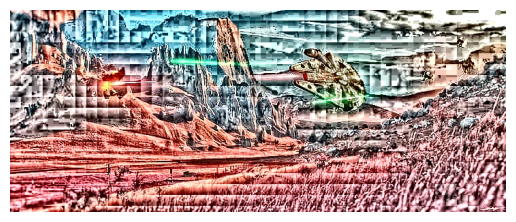

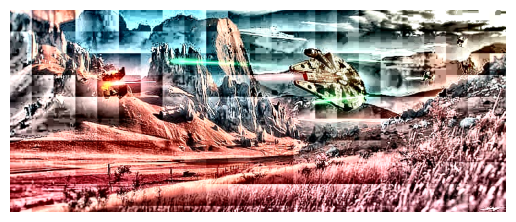

In [6]:
show_image(ahe(img1_array.copy(), kernel_size_h=100, kernel_size_w=100, show_hist=True))
show_image(ahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8, show_hist=False))
show_image(ahe(img1_array.copy(), kernel_size_h=16, kernel_size_w=16, show_hist=False))
show_image(ahe(img1_array.copy(), kernel_size_h=32, kernel_size_w=32, show_hist=False))

### Pregunta 2

Investiga e implementa un método sencillo del Sliding Window Adaptive Histogram Equalization (SWAHE) y compara algunas imágenes con diferentes tipos de imágenes.

#### Respuesta

El método es el siguiente:

1. Se define el tamaño de la ventana, por ejemplo, $n \times m$.
2. Se centra la ventana en el primer píxel válido. La parte de la ventana que queda fuera de la imagen se considera con valor cero.
3. Se calcula el histograma de esta ventana y se ecualiza el píxel central.
4. Se avanza al siguiente píxel. Como la ventana se desplaza solo un píxel, muchos valores permanecen en el histograma. Para optimizar el proceso, se restan los píxeles que salen de la ventana y solo se suman los que entran. Este paso es más complejo; por ello, en esta implementación sencilla se recalcula el histograma completo para cada ventana.
5. Se repite el proceso hasta recorrer toda la imagen.

In [7]:
def swahe(img_array, kernel_size_h=100, kernel_size_w=100):
    img_to_process, is_grayscale, img_array_ycbcr = get_image_to_process(img_array)
    img_to_process = np.clip(np.rint(img_to_process), 0, 255).astype(np.uint8)

    pad_height = kernel_size_h // 2
    pad_width = kernel_size_w // 2

    source = np.pad(
        img_to_process,
        ((pad_height, pad_height), (pad_width, pad_width)),
        mode="reflect",
    )
    output_img = np.zeros_like(source)

    for i in range(pad_height, source.shape[0] - pad_height):
        for j in range(pad_width, source.shape[1] - pad_width):
            kernel = source[
                i - pad_height : i + pad_height + 1,
                j - pad_width : j + pad_width + 1,
            ]

            hist, _ = np.histogram(kernel.flatten(), 256, [0, 256])
            cdf = hist.cumsum()
            cdf_normalized = cdf * 255 / cdf[-1]

            center_pixel = source[i, j]
            output_img[i, j] = cdf_normalized[center_pixel]

    output_img = output_img[
        pad_height:-pad_height,
        pad_width:-pad_width,
    ]

    if is_grayscale:
        return output_img, is_grayscale, img_array_ycbcr

    img_array_ycbcr[:, :, 0] = output_img
    return ycbcr2rgb(img_array_ycbcr), is_grayscale, img_array_ycbcr

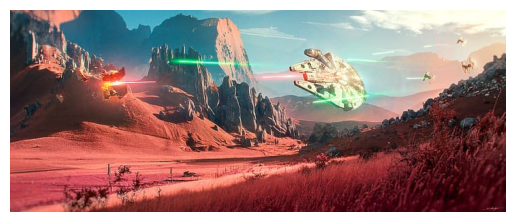

In [8]:
# imagen original
show_image(img1_array)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4271948428686542..1.474532044050497].


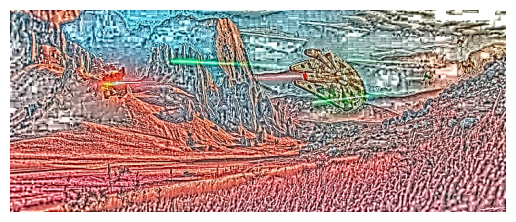

In [9]:
show_image(swahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8)[0])

### Pregunta 3

Investiga cómo funciona el algoritmo CLAHE (contrast limited adaptive histogram equalization) y realiza una implementación (puede ser usando la implementación de OpenCV). Prueba sobre diferentes tipos de imágenes y compara con el método de ecualización de histogramas básico. Provee una breve descripción del método a partir de una  investigación bibliográfica.

#### Respuesta

Como se mencionó anteriormente, a diferencia del método de ventanas móviles, CLAHE retoma el enfoque de AHE al dividir la imagen en un número determinado de regiones. Sin embargo, introduce un concepto adicional: el límite de contraste. Este método fue presentado por primera vez por Karel Zuiderveld en 1994.

De manera intuitiva, CLAHE limita los picos del histograma a un valor establecido. Esto es especialmente útil en zonas con poca variación de intensidad, cuyos histogramas pueden presentar picos muy altos. Al limitar estos picos, se evita una amplificación excesiva del contraste y se reducen las transiciones abruptas entre regiones.

El método funciona de la siguiente manera:

1. Se siguen los mismos pasos que en AHE, con la diferencia de que primero se establece un umbral máximo para los picos de los histogramas.
2. Si el histograma de una región contiene un pico mayor que el umbral, dicho pico se recorta. Los valores excedentes se redistribuyen de manera equitativa entre los demás niveles de intensidad. Si, después de la redistribución, se vuelve a superar el límite, el proceso se repite.
3. El mismo procedimiento se aplica a todas las regiones de la imagen.
4. Se calcula la función de distribución acumulada (CDF) para cada región.
5. Se aplica interpolación bilineal entre las regiones vecinas para obtener la imagen final y evitar transiciones visibles entre mosaicos.

##### Referencia
OpenCV. (2025). Histograms - 2: Histogram Equalization. OpenCV 4.13.0 Documentation. opencv.org
Zuiderveld, K. (1994). Contrast Limited Adaptive Histogram Equalization. In P. Heckbert (Ed.), Graphics Gems IV (pp. 474–485). Academic Press Professional. ISBN: 978-0-12-336155-4.

In [10]:
def clahe(img_array, kernel_size_h=100, kernel_size_w=100, clip_limit=2.0):
    img_to_process, is_grayscale, img_array_ycbcr = get_image_to_process(img_array)

    img_to_process = np.clip(
        np.rint(img_to_process), 0, 255
    ).astype(np.uint8)

    height, width = img_to_process.shape

    # OpenCV recibe el número de mosaicos, no su tamaño en píxeles.
    tile_rows = max(1, (height + kernel_size_h - 1) // kernel_size_h)
    tile_cols = max(1, (width + kernel_size_w - 1) // kernel_size_w)

    clahe_op = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=(tile_cols, tile_rows),
    )
    output_img = clahe_op.apply(img_to_process)

    if is_grayscale:
        return output_img

    img_array_ycbcr[:, :, 0] = output_img
    rgb_result = ycbcr2rgb(img_array_ycbcr)

    return np.clip(rgb_result * 255, 0, 255).astype(np.uint8)

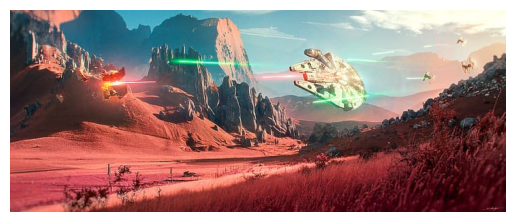

In [11]:
# imagen original
show_image(img1_array)

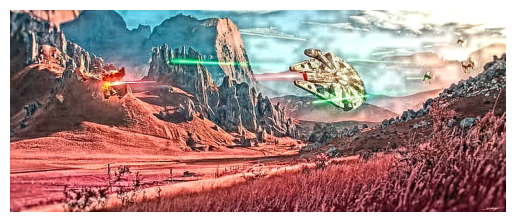

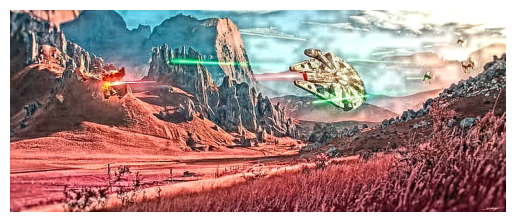

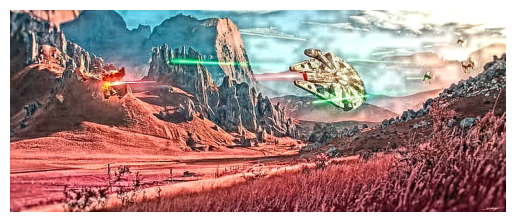

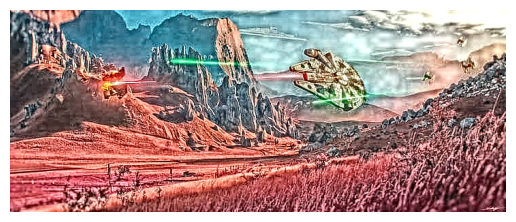

In [12]:
show_image(clahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8, clip_limit=0.1))
show_image(clahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8, clip_limit=2.0))
show_image(clahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8, clip_limit=2.2))
show_image(clahe(img1_array.copy(), kernel_size_h=8, kernel_size_w=8, clip_limit=10.0))